# Architecture Comparison: Dataset Size Sweep Validation

This notebook validates the behavior of three different architectures across varying dataset sizes:
1. **DINOv2 + MLP** (feature-space training)
2. **CNN MC Dropout** (end-to-end training)
3. **ResNet18 MC Dropout** (end-to-end training)

## Expected Behaviors
- **Accuracy**: Should increase with more training data
- **Epistemic Uncertainty**: Should decrease with more training data (model becomes more confident)
- **Aleatoric Uncertainty**: Should remain relatively stable (inherent data noise)
- **Consistency**: All three architectures should show similar behavioral patterns

## Dataset Size Sweep Parameters
- Test with: 50, 100, 200, 300, 500 samples per class
- Dataset: CIFAR-10N with "worse_label" noise type
- Keep other parameters constant across architectures

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
import subprocess
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Python version: {sys.version}")

Project root: /Users/andrearachetta/Documents/old_pilots/walaris-cen
Python version: 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]


## 2. Configuration

Define the experimental parameters for the dataset size sweep.

In [2]:
# Dataset size sweep parameters
DATASET_SIZES = [50, 100, 200, 300, 500]  # samples per class

# Architecture configurations
ARCHITECTURES = {
    'dinov2_mlp': {
        'name': 'DINOv2 + MLP',
        'config_template': 'configs/test/test_dinov2_mlp.yaml',
        'color': '#1f77b4',
        'marker': 'o',
        'training_mode': 'feature_space'
    },
    'cnn_mcdropout': {
        'name': 'CNN MC Dropout',
        'config_template': 'configs/test/test_cnn_mcdropout.yaml',
        'color': '#ff7f0e',
        'marker': 's',
        'training_mode': 'end_to_end'
    },
    'resnet18_mcdropout': {
        'name': 'ResNet18 MC Dropout',
        'config_template': 'configs/test/test_resnet18_mcdropout.yaml',
        'color': '#2ca02c',
        'marker': '^',
        'training_mode': 'end_to_end'
    }
}

# Common parameters
NOISE_TYPE = 'worse_label'
EVAL_PER_GROUP = 100
MC_PASSES = 30  # More passes for better uncertainty estimates
EPOCHS = 10  # Reasonable training for validation

# Results directory
RESULTS_DIR = project_root / 'results' / 'validation' / 'dataset_size_sweep'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: /Users/andrearachetta/Documents/old_pilots/walaris-cen/results/validation/dataset_size_sweep


## 3. Experiment Runner

Functions to run experiments or load existing results.

In [3]:
def create_config_for_size(arch_key, dataset_size, base_config_path):
    """Create a temporary config file for a specific dataset size."""
    with open(project_root / base_config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    # Update dataset size
    config['dataset']['regular_train_per_class'] = dataset_size
    config['dataset']['eval_per_group'] = EVAL_PER_GROUP
    
    # Update training parameters
    config['training']['epochs'] = EPOCHS
    config['evaluation']['mc_passes'] = MC_PASSES
    
    # Create temp config file
    temp_config_path = RESULTS_DIR / f'temp_config_{arch_key}_{dataset_size}.yaml'
    with open(temp_config_path, 'w') as f:
        yaml.dump(config, f)
    
    return temp_config_path


def run_experiment(arch_key, dataset_size, arch_config):
    """Run a single experiment for a given architecture and dataset size."""
    print(f"\nRunning {arch_config['name']} with {dataset_size} samples/class...")
    
    # Create config
    config_path = create_config_for_size(
        arch_key, dataset_size, arch_config['config_template']
    )
    
    # Run training script
    script_path = project_root / 'scripts' / 'run_fast_uncertainty_classification.py'
    cmd = [
        'python', str(script_path),
        '--config', str(config_path),
        '--results-dir', str(RESULTS_DIR / f'{arch_key}_{dataset_size}')
    ]
    
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            cwd=project_root,
            timeout=3600  # 1 hour timeout
        )
        
        if result.returncode != 0:
            print(f"Error running experiment: {result.stderr}")
            return None
        
        # Load results
        results_file = RESULTS_DIR / f'{arch_key}_{dataset_size}' / 'results.json'
        if results_file.exists():
            with open(results_file, 'r') as f:
                return json.load(f)
        else:
            print(f"Results file not found: {results_file}")
            return None
            
    except subprocess.TimeoutExpired:
        print(f"Experiment timed out after 1 hour")
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None


def load_or_run_experiments(run_new=False):
    """Load existing results or run new experiments."""
    results = {arch: {} for arch in ARCHITECTURES.keys()}
    
    # Try to load from metrics.csv first
    metrics_csv = RESULTS_DIR / 'metrics.csv'
    if metrics_csv.exists() and not run_new:
        print(f"Loading results from {metrics_csv}")
        df = pd.read_csv(metrics_csv)
        
        # Map architecture names in CSV to our keys
        arch_name_map = {
            'DINOv2 + MLP': 'dinov2_mlp',
            'CNN MC Dropout': 'cnn_mcdropout',
            'ResNet18 MC Dropout': 'resnet18_mcdropout'
        }
        
        for _, row in df.iterrows():
            arch_name = row['architecture']
            arch_key = arch_name_map.get(arch_name)
            if arch_key and arch_key in results:
                size = int(row['dataset_size'])
                results[arch_key][size] = row.to_dict()
                print(f"Loaded {arch_name} @ {size} samples/class")
        
        return results
    
    # Fallback to individual results.json files
    for arch_key, arch_config in ARCHITECTURES.items():
        for size in DATASET_SIZES:
            results_file = RESULTS_DIR / f'{arch_key}_size{size}' / 'results.json'
            
            if results_file.exists() and not run_new:
                print(f"Loading existing results for {arch_config['name']} @ {size}")
                with open(results_file, 'r') as f:
                    results[arch_key][size] = json.load(f)
            elif run_new:
                result = run_experiment(arch_key, size, arch_config)
                if result:
                    results[arch_key][size] = result
            else:
                print(f"No results found for {arch_config['name']} @ {size}")
    
    return results

print("Experiment runner functions defined.")

Experiment runner functions defined.


## 4. Load or Run Experiments

Set `RUN_NEW_EXPERIMENTS = True` to run new experiments, or `False` to load existing results.

In [4]:
# Set to True to run new experiments, False to load existing
RUN_NEW_EXPERIMENTS = False

print(f"Mode: {'Running new experiments' if RUN_NEW_EXPERIMENTS else 'Loading existing results'}")
results = load_or_run_experiments(run_new=RUN_NEW_EXPERIMENTS)

# Check what we have
for arch_key, arch_results in results.items():
    print(f"\n{ARCHITECTURES[arch_key]['name']}: {len(arch_results)} dataset sizes")
    for size in sorted(arch_results.keys()):
        print(f"  - {size} samples/class")

Mode: Loading existing results
No results found for DINOv2 + MLP @ 50
No results found for DINOv2 + MLP @ 100
No results found for DINOv2 + MLP @ 200
No results found for DINOv2 + MLP @ 300
No results found for DINOv2 + MLP @ 500
No results found for CNN MC Dropout @ 50
No results found for CNN MC Dropout @ 100
No results found for CNN MC Dropout @ 200
No results found for CNN MC Dropout @ 300
No results found for CNN MC Dropout @ 500
No results found for ResNet18 MC Dropout @ 50
No results found for ResNet18 MC Dropout @ 100
No results found for ResNet18 MC Dropout @ 200
No results found for ResNet18 MC Dropout @ 300
No results found for ResNet18 MC Dropout @ 500

DINOv2 + MLP: 0 dataset sizes

CNN MC Dropout: 0 dataset sizes

ResNet18 MC Dropout: 0 dataset sizes


## 5. Extract Metrics

Extract key metrics from the results for analysis.

In [5]:
def extract_metrics(results):
    """Extract metrics from results into a structured format."""
    metrics = {
        'architecture': [],
        'dataset_size': [],
        'accuracy': [],
        'mean_epistemic_uncertainty': [],
        'epistemic_std': [],
        'mean_aleatoric_uncertainty': [],
        'aleatoric_std': [],
        'mean_total_uncertainty': [],
        'training_time': []
    }
    
    for arch_key, arch_results in results.items():
        arch_name = ARCHITECTURES[arch_key]['name']
        
        for size, result in arch_results.items():
            if result is None:
                continue
                
            metrics['architecture'].append(arch_name)
            metrics['dataset_size'].append(size)
            
            # Extract accuracy (from classification metrics)
            clf_metrics = result.get('classification_metrics', {})
            metrics['accuracy'].append(clf_metrics.get('accuracy', np.nan))
            
            # Extract uncertainty metrics
            uq_metrics = result.get('uncertainty_metrics', {})
            metrics['mean_epistemic_uncertainty'].append(uq_metrics.get('mean_epistemic_uncertainty', np.nan))
            metrics['epistemic_std'].append(uq_metrics.get('epistemic_std', np.nan))
            metrics['mean_aleatoric_uncertainty'].append(uq_metrics.get('mean_aleatoric_uncertainty', np.nan))
            metrics['aleatoric_std'].append(uq_metrics.get('aleatoric_std', np.nan))
            metrics['mean_total_uncertainty'].append(
                uq_metrics.get('mean_epistemic_uncertainty', 0) + uq_metrics.get('mean_aleatoric_uncertainty', 0)
            )
            
            # Extract training time
            metrics['training_time'].append(result.get('training_time_seconds', np.nan))
    
    return pd.DataFrame(metrics)


# Extract metrics
df_metrics = extract_metrics(results)
print(f"\nExtracted metrics for {len(df_metrics)} experiments")
print(f"\nDataFrame shape: {df_metrics.shape}")
print("\nFirst few rows:")
display(df_metrics.head(10))

# Summary statistics
print("\nSummary by architecture:")
display(df_metrics.groupby('architecture').agg({
    'accuracy': ['mean', 'std'],
    'mean_epistemic_uncertainty': ['mean', 'std'],
    'mean_aleatoric_uncertainty': ['mean', 'std']
}).round(4))


Extracted metrics for 0 experiments

DataFrame shape: (0, 9)

First few rows:


,architecture,dataset_size,accuracy,mean_epistemic_uncertainty,epistemic_std,mean_aleatoric_uncertainty,aleatoric_std,mean_total_uncertainty,training_time



Summary by architecture:


Empty DataFrame
Columns: [(accuracy, mean), (accuracy, std), (mean_epistemic_uncertainty, mean), (mean_epistemic_uncertainty, std), (mean_aleatoric_uncertainty, mean), (mean_aleatoric_uncertainty, std)]
Index: []

## 6. Visualization: Dual Y-Axis Plots

Following the pattern from `dataset_size_toy.ipynb`, create dual y-axis plots showing:
- **Left axis**: Accuracy (should increase)
- **Right axis**: Uncertainty (epistemic should decrease)

Saved plot to: /Users/andrearachetta/Documents/old_pilots/walaris-cen/results/validation/dataset_size_sweep/dual_axis_accuracy_mean_epistemic_uncertainty.png


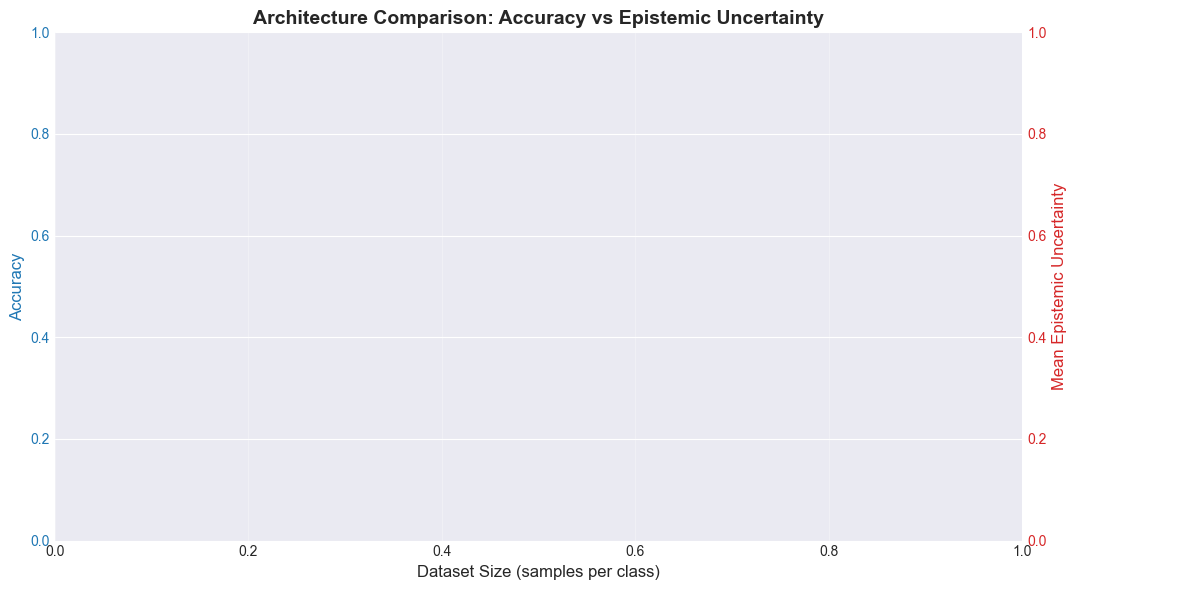

In [6]:
def plot_dual_axis_comparison(df, metric_left='accuracy', metric_right='mean_epistemic_uncertainty',
                              title='Architecture Comparison: Dataset Size Sweep'):
    """Create dual y-axis plot comparing architectures."""
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Left y-axis (accuracy)
    ax1.set_xlabel('Dataset Size (samples per class)', fontsize=12)
    ax1.set_ylabel(metric_left.replace('_', ' ').title(), color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)
    
    # Right y-axis (uncertainty)
    ax2 = ax1.twinx()
    ax2.set_ylabel(metric_right.replace('_', ' ').title(), color='tab:red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    # Plot each architecture
    for arch_key, arch_config in ARCHITECTURES.items():
        arch_name = arch_config['name']
        arch_data = df[df['architecture'] == arch_name].sort_values('dataset_size')
        
        if len(arch_data) == 0:
            continue
        
        x = arch_data['dataset_size']
        
        # Plot accuracy (left axis) - solid line
        ax1.plot(x, arch_data[metric_left], 
                color=arch_config['color'],
                marker=arch_config['marker'],
                linestyle='-',
                linewidth=2,
                markersize=8,
                label=f"{arch_name} ({metric_left})")
        
        # Plot uncertainty (right axis) - dashed line
        ax2.plot(x, arch_data[metric_right],
                color=arch_config['color'],
                marker=arch_config['marker'],
                linestyle='--',
                linewidth=2,
                markersize=8,
                alpha=0.7,
                label=f"{arch_name} ({metric_right})")
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.15, 0.5))
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    save_path = RESULTS_DIR / f'dual_axis_{metric_left}_{metric_right}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to: {save_path}")
    
    plt.show()


# Create main comparison plot
plot_dual_axis_comparison(
    df_metrics,
    metric_left='accuracy',
    metric_right='mean_epistemic_uncertainty',
    title='Architecture Comparison: Accuracy vs Epistemic Uncertainty'
)

## 7. Additional Visualizations

Saved plot to: /Users/andrearachetta/Documents/old_pilots/walaris-cen/results/validation/dataset_size_sweep/dual_axis_accuracy_mean_aleatoric_uncertainty.png


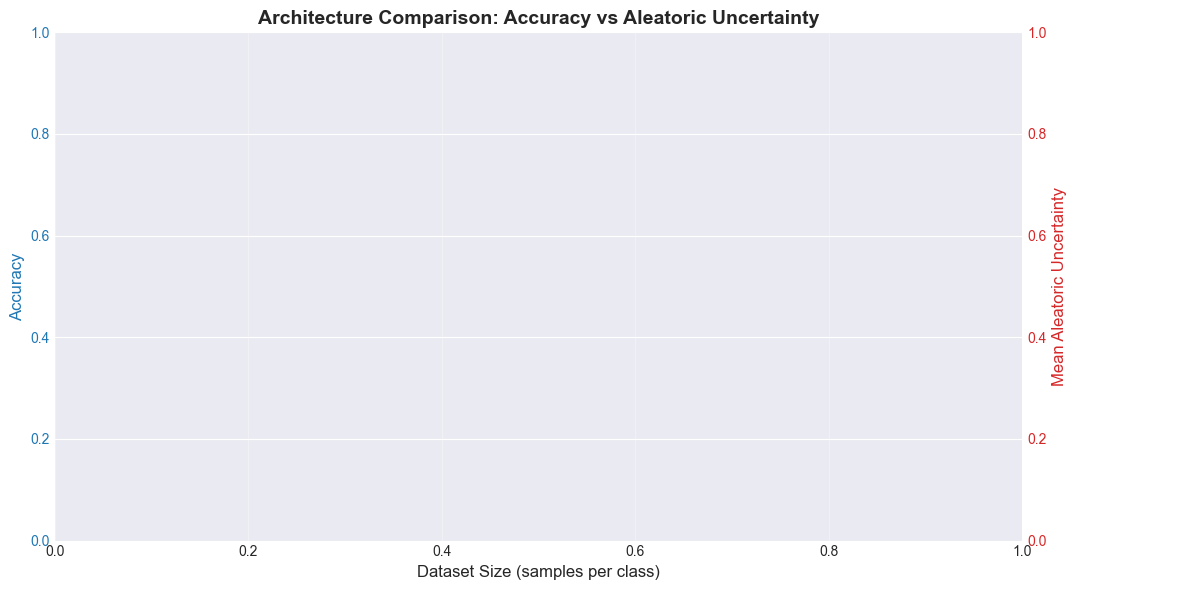

In [7]:
# Plot aleatoric uncertainty
plot_dual_axis_comparison(
    df_metrics,
    metric_left='accuracy',
    metric_right='mean_aleatoric_uncertainty',
    title='Architecture Comparison: Accuracy vs Aleatoric Uncertainty'
)

Saved plot to: /Users/andrearachetta/Documents/old_pilots/walaris-cen/results/validation/dataset_size_sweep/dual_axis_accuracy_mean_total_uncertainty.png


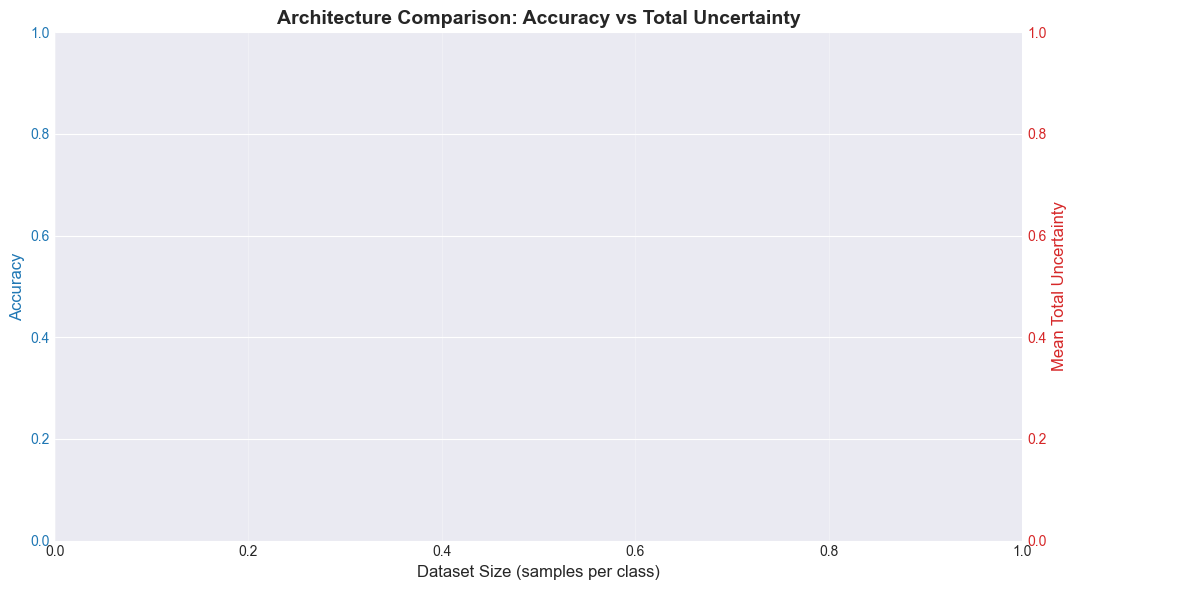

In [8]:
# Plot total uncertainty
plot_dual_axis_comparison(
    df_metrics,
    metric_left='accuracy',
    metric_right='mean_total_uncertainty',
    title='Architecture Comparison: Accuracy vs Total Uncertainty'
)

Saved plot to: /Users/andrearachetta/Documents/old_pilots/walaris-cen/results/validation/dataset_size_sweep/individual_metrics.png


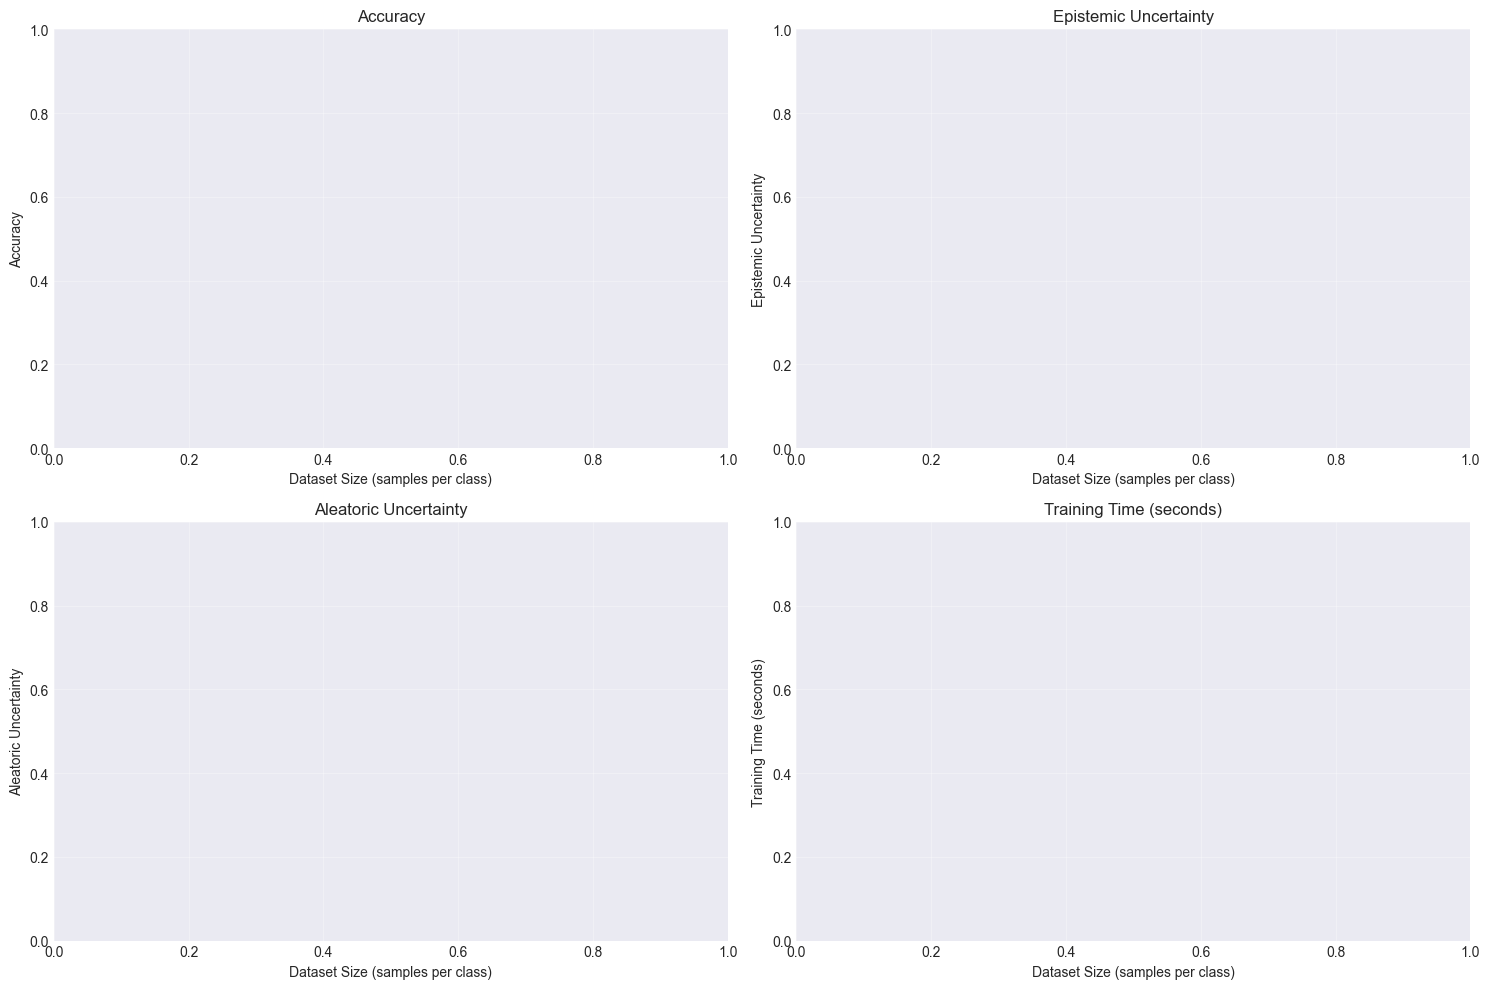

In [9]:
# Separate plots for each metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = [
    ('accuracy', 'Accuracy', axes[0, 0]),
    ('mean_epistemic_uncertainty', 'Epistemic Uncertainty', axes[0, 1]),
    ('mean_aleatoric_uncertainty', 'Aleatoric Uncertainty', axes[1, 0]),
    ('training_time', 'Training Time (seconds)', axes[1, 1])
]

for metric, label, ax in metrics_to_plot:
    for arch_key, arch_config in ARCHITECTURES.items():
        arch_name = arch_config['name']
        arch_data = df_metrics[df_metrics['architecture'] == arch_name].sort_values('dataset_size')
        
        if len(arch_data) > 0:
            ax.plot(arch_data['dataset_size'], arch_data[metric],
                   color=arch_config['color'],
                   marker=arch_config['marker'],
                   linewidth=2,
                   markersize=8,
                   label=arch_name)
    
    ax.set_xlabel('Dataset Size (samples per class)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = RESULTS_DIR / 'individual_metrics.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to: {save_path}")
plt.show()

## 8. Statistical Validation

Perform statistical tests to validate expected behaviors.

In [10]:
def validate_trend(df, architecture, metric, expected_direction='increase'):
    """Validate that a metric follows the expected trend with dataset size.
    
    Args:
        df: DataFrame with metrics
        architecture: Architecture name
        metric: Metric to test
        expected_direction: 'increase' or 'decrease'
    
    Returns:
        dict with test results
    """
    arch_data = df[df['architecture'] == architecture].sort_values('dataset_size')
    
    if len(arch_data) < 3:
        return {'error': 'Insufficient data points'}
    
    x = arch_data['dataset_size'].values
    y = arch_data[metric].values
    
    # Remove NaN values
    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]
    
    if len(x) < 3:
        return {'error': 'Insufficient valid data points'}
    
    # Spearman correlation (monotonic relationship)
    corr, p_value = stats.spearmanr(x, y)
    
    # Linear regression
    slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)
    
    # Check if trend matches expectation
    if expected_direction == 'increase':
        trend_correct = slope > 0 and corr > 0
    else:  # decrease
        trend_correct = slope < 0 and corr < 0
    
    return {
        'architecture': architecture,
        'metric': metric,
        'expected_direction': expected_direction,
        'spearman_corr': corr,
        'spearman_p': p_value,
        'linear_slope': slope,
        'linear_r2': r_value**2,
        'linear_p': p_value_reg,
        'trend_correct': trend_correct,
        'significant': p_value < 0.05
    }


# Run validation tests
validation_results = []

for arch_key, arch_config in ARCHITECTURES.items():
    arch_name = arch_config['name']
    
    # Test 1: Accuracy should increase
    validation_results.append(
        validate_trend(df_metrics, arch_name, 'accuracy', 'increase')
    )
    
    # Test 2: Epistemic uncertainty should decrease
    validation_results.append(
        validate_trend(df_metrics, arch_name, 'mean_epistemic_uncertainty', 'decrease')
    )

# Create validation summary
df_validation = pd.DataFrame(validation_results)
print("\n" + "="*80)
print("VALIDATION RESULTS")
print("="*80)
display(df_validation)

# Summary of validation
print("\n" + "="*80)
print("VALIDATION SUMMARY")
print("="*80)

for arch_key, arch_config in ARCHITECTURES.items():
    arch_name = arch_config['name']
    arch_results = df_validation[df_validation['architecture'] == arch_name]
    
    print(f"\n{arch_name}:")
    
    for _, row in arch_results.iterrows():
        if 'error' in row:
            print(f"  ❌ {row['metric']}: {row['error']}")
        else:
            status = "✅" if row['trend_correct'] and row['significant'] else "⚠️"
            print(f"  {status} {row['metric']} ({row['expected_direction']}):")
            print(f"     Spearman ρ = {row['spearman_corr']:.3f} (p = {row['spearman_p']:.4f})")
            print(f"     Linear R² = {row['linear_r2']:.3f}, slope = {row['linear_slope']:.6f}")


VALIDATION RESULTS


,error
0,Insufficient data points
1,Insufficient data points
2,Insufficient data points
3,Insufficient data points
4,Insufficient data points
5,Insufficient data points



VALIDATION SUMMARY


KeyError: 'architecture'

## 9. Cross-Architecture Comparison

Compare architectures at each dataset size.

In [ ]:
def compare_architectures_at_size(df, dataset_size):
    """Compare all architectures at a specific dataset size."""
    size_data = df[df['dataset_size'] == dataset_size]
    
    if len(size_data) == 0:
        print(f"No data for dataset size {dataset_size}")
        return
    
    print(f"\n{'='*80}")
    print(f"COMPARISON AT {dataset_size} SAMPLES PER CLASS")
    print(f"{'='*80}\n")
    
    # Create comparison table
    comparison = size_data[[
        'architecture', 'accuracy', 'mean_epistemic_uncertainty', 'mean_aleatoric_uncertainty', 
        'mean_total_uncertainty', 'training_time'
    ]].copy()
    
    comparison = comparison.sort_values('accuracy', ascending=False)
    display(comparison)
    
    # Statistical tests
    if len(size_data) >= 2:
        print("\nStatistical Tests:")
        
        # Kruskal-Wallis test (non-parametric ANOVA)
        for metric in ['accuracy', 'mean_epistemic_uncertainty', 'mean_aleatoric_uncertainty']:
            groups = [size_data[size_data['architecture'] == arch][metric].values 
                     for arch in size_data['architecture'].unique()]
            groups = [g for g in groups if len(g) > 0 and not np.all(np.isnan(g))]
            
            if len(groups) >= 2:
                try:
                    stat, p = stats.kruskal(*groups)
                    print(f"  {metric}: H = {stat:.3f}, p = {p:.4f}")
                except:
                    print(f"  {metric}: Could not compute test")


# Compare at each dataset size
for size in sorted(df_metrics['dataset_size'].unique()):
    compare_architectures_at_size(df_metrics, size)

## 10. Behavioral Pattern Analysis

Analyze if all architectures show similar behavioral patterns.

In [ ]:
def analyze_behavioral_patterns(df):
    """Analyze if architectures show similar behavioral patterns."""
    print("\n" + "="*80)
    print("BEHAVIORAL PATTERN ANALYSIS")
    print("="*80)
    
    architectures = df['architecture'].unique()
    
    # Normalize metrics for comparison
    metrics_to_analyze = ['accuracy', 'mean_epistemic_uncertainty', 'mean_aleatoric_uncertainty']
    
    for metric in metrics_to_analyze:
        print(f"\n{metric.upper()}:")
        
        # Get normalized curves for each architecture
        curves = {}
        for arch in architectures:
            arch_data = df[df['architecture'] == arch].sort_values('dataset_size')
            if len(arch_data) > 0:
                values = arch_data[metric].values
                # Normalize to [0, 1]
                if np.ptp(values) > 0:  # Check if there's variation
                    normalized = (values - np.min(values)) / np.ptp(values)
                else:
                    normalized = values
                curves[arch] = normalized
        
        # Compare curves pairwise
        if len(curves) >= 2:
            arch_list = list(curves.keys())
            for i in range(len(arch_list)):
                for j in range(i+1, len(arch_list)):
                    arch1, arch2 = arch_list[i], arch_list[j]
                    
                    # Ensure same length
                    min_len = min(len(curves[arch1]), len(curves[arch2]))
                    curve1 = curves[arch1][:min_len]
                    curve2 = curves[arch2][:min_len]
                    
                    # Compute correlation
                    if len(curve1) >= 3:
                        corr, p_value = stats.pearsonr(curve1, curve2)
                        print(f"  {arch1} vs {arch2}: r = {corr:.3f} (p = {p_value:.4f})")
                        
                        if corr > 0.7:
                            print(f"    ✅ Strong positive correlation - similar patterns")
                        elif corr < -0.7:
                            print(f"    ⚠️ Strong negative correlation - opposite patterns")
                        else:
                            print(f"    ⚠️ Weak correlation - different patterns")


analyze_behavioral_patterns(df_metrics)

## 11. Final Summary and Conclusions

In [ ]:
def generate_summary_report(df, validation_df):
    """Generate a comprehensive summary report."""
    print("\n" + "="*80)
    print("FINAL VALIDATION SUMMARY")
    print("="*80)
    
    # Overall statistics
    print("\n1. OVERALL STATISTICS:")
    print(f"   - Total experiments: {len(df)}")
    print(f"   - Architectures tested: {df['architecture'].nunique()}")
    print(f"   - Dataset sizes: {sorted(df['dataset_size'].unique())}")
    
    # Best performing architecture
    print("\n2. BEST PERFORMING ARCHITECTURE (by accuracy):")
    best_by_size = df.loc[df.groupby('dataset_size')['accuracy'].idxmax()]
    for _, row in best_by_size.iterrows():
        print(f"   - {int(row['dataset_size'])} samples/class: {row['architecture']} "
              f"(acc={row['accuracy']:.4f})")
    
    # Validation results summary
    print("\n3. VALIDATION CHECKS:")
    
    if 'trend_correct' in validation_df.columns:
        total_checks = len(validation_df)
        passed_checks = validation_df['trend_correct'].sum()
        significant_checks = validation_df['significant'].sum()
        
        print(f"   - Total validation checks: {total_checks}")
        print(f"   - Checks passed: {passed_checks} ({100*passed_checks/total_checks:.1f}%)")
        print(f"   - Statistically significant: {significant_checks} "
              f"({100*significant_checks/total_checks:.1f}%)")
    
    # Key findings
    print("\n4. KEY FINDINGS:")
    
    for arch in df['architecture'].unique():
        arch_data = df[df['architecture'] == arch].sort_values('dataset_size')
        
        if len(arch_data) >= 2:
            acc_change = arch_data['accuracy'].iloc[-1] - arch_data['accuracy'].iloc[0]
            epi_change = arch_data['mean_epistemic_uncertainty'].iloc[-1] - arch_data['mean_epistemic_uncertainty'].iloc[0]
            
            print(f"\n   {arch}:")
            print(f"   - Accuracy change: {acc_change:+.4f} "
                  f"({100*acc_change/arch_data['accuracy'].iloc[0]:+.1f}%)")
            print(f"   - Epistemic uncertainty change: {epi_change:+.6f} "
                  f"({100*epi_change/arch_data['mean_epistemic_uncertainty'].iloc[0]:+.1f}%)")
            print(f"   - Average training time: {arch_data['training_time'].mean():.1f}s")
    
    print("\n" + "="*80)


# Generate final report
generate_summary_report(df_metrics, df_validation)

# Save summary to file
summary_path = RESULTS_DIR / 'validation_summary.txt'
with open(summary_path, 'w') as f:
    f.write("ARCHITECTURE COMPARISON VALIDATION SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(f"Generated: {pd.Timestamp.now()}\n\n")
    f.write(df_metrics.to_string())
    f.write("\n\n" + "="*80 + "\n")
    f.write("VALIDATION RESULTS\n")
    f.write("="*80 + "\n\n")
    f.write(df_validation.to_string())

print(f"\nSummary saved to: {summary_path}")

## 12. Export Results

In [ ]:
# Save metrics to CSV
metrics_path = RESULTS_DIR / 'metrics.csv'
df_metrics.to_csv(metrics_path, index=False)
print(f"Metrics saved to: {metrics_path}")

# Save validation results to CSV
validation_path = RESULTS_DIR / 'validation_results.csv'
df_validation.to_csv(validation_path, index=False)
print(f"Validation results saved to: {validation_path}")

print("\n✅ All results exported successfully!")